In [1]:
import numpy as np
import matplotlib.pyplot as mlt
import math

In [2]:
x1 = [1,2,3,4,5]
y1 = [-8,-3,20,73,168]
x2 = [0,1,2,3,4]
y2 = [-10,-9,10,65,174]
x3 = [1,4,3,5]
y3 = [1,3,4,5]

In [3]:
def invalid_data_check(x,y):
    n = len(x)
    x=np.array(x)
    if len(y) != n or not np.allclose(np.diff(x), np.diff(x)[0]):
        return True
    return False

In [4]:
def difference_table(x, y, forward = True):
    if invalid_data_check(x,y):
        print('Invalid Data')
        return None
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    forwardtable = np.zeros((n,n))
    backwardtable = np.zeros((n,n))
    backwardtable[:,0] = y
    forwardtable[:,0] = y
    for i in range(1,n):
        forwardtable[0:n-i, i] = forwardtable[1:n-i+1, i-1] - forwardtable[0:n-i, i-1]
    if forward:
        return forwardtable
    for i in range(1,n):
        backwardtable[i:n+1, i] = forwardtable[0:n-i, i]
    return backwardtable

In [5]:
#Test 1.1
x1_y1_fdtable = difference_table(x1,y1)

In [6]:
#Test 1.2
x1_y1_bktable = difference_table(x1,y1, False)

In [7]:
#Test 1.3
x2_y2_fdtable = difference_table(x2,y2)

In [8]:
#Test 1.4
x2_y2_bktable = difference_table(x2,y2, False)

In [9]:
#Test 1.5
x3_y3_fdtable = difference_table(x3,y3)

Invalid Data


In [10]:
def newtons_forward_interpolation(x,fdtable,x_point,show = True):
    n = len(x)
    if invalid_data_check(x,fdtable[:,0]):
        print('Invalid data')
        return None
    p = (x_point - x[0])/(x[1] - x[0])
    y_point = 0
    for i in range(n):
        p_temp = p
        intermediate = 1
        for j in range(i):
            intermediate *= p_temp
            p_temp-=1
        intermediate/=math.factorial(i)
        y_point+= intermediate*fdtable[0,i]
    if show:
        plotfunc_with_interpolated_highlight(x,fdtable,x_point,newtons_forward_interpolation)
    return y_point

In [11]:
def newtons_backward_interpolation(x,bktable,x_point,show = True):
    n = len(x)
    if invalid_data_check(x,bktable[:,0]):
        print('Invalid data(unequal interval)')
        return None
    p = (x_point - x[n-1])/(x[1] - x[0])
    y_point = 0
    for i in range(n):
        p_temp = p
        intermediate = 1
        for j in range(i):
            intermediate *= p_temp
            p_temp+=1
        intermediate/=math.factorial(i)
        y_point+= intermediate*bktable[n-1,i]
    if show:
        plotfunc_with_interpolated_highlight(x,bktable,x_point,newtons_backward_interpolation)
    return y_point

In [12]:
def plotfunc_with_interpolated_highlight(x,table,x_point,f):
    x_plot = np.linspace(min(x),max(x),1000)
    y_plot = [f(x,table,xi,False) for xi in x_plot]
    mlt.figure()
    mlt.grid()
    mlt.plot(x_plot, y_plot, label = 'Interpolation Curve')
    mlt.scatter(x_point,f(x,table,x_point,False), color = "red", label = 'Interpolated Point', zorder = 5)
    mlt.scatter(x,table[:,0], color = 'green', label = 'Data Points', zorder = 5)
    mlt.legend()
    mlt.show()

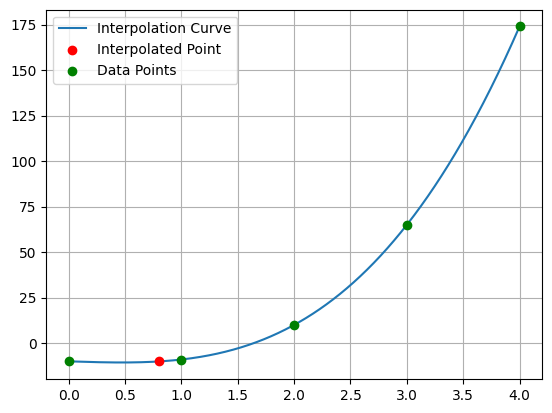

np.float64(-10.063999999999998)

In [13]:
#Test 2.1
newtons_forward_interpolation(x2,x2_y2_fdtable,0.8)

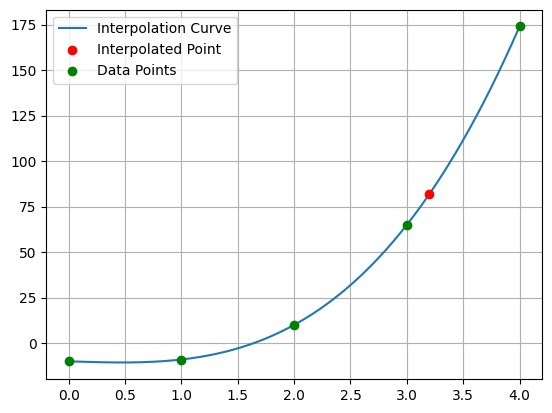

np.float64(81.90400000000002)

In [14]:
#Test 2.2
newtons_forward_interpolation(x2,x2_y2_fdtable,3.2)

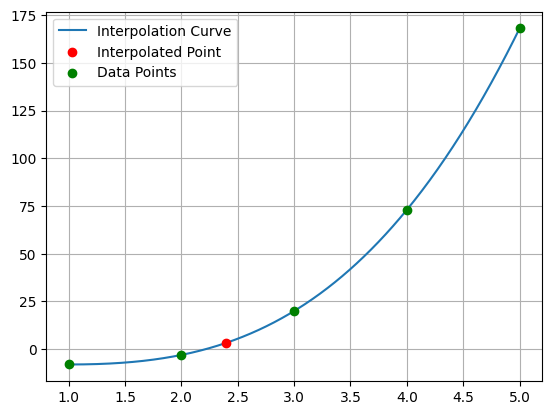

np.float64(3.3679999999999986)

In [15]:
#Test 2.3
newtons_forward_interpolation(x1,x1_y1_fdtable,2.4)

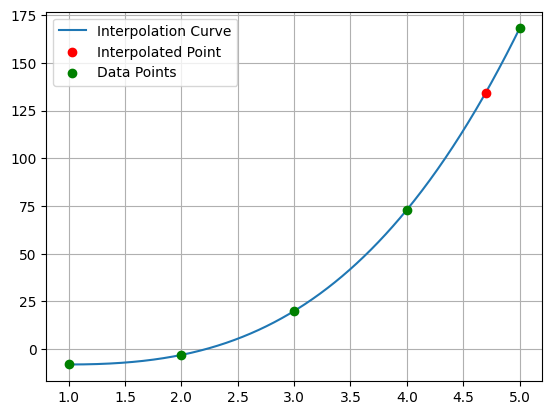

np.float64(134.37600000000003)

In [16]:
#Test 2.4
newtons_forward_interpolation(x1,x1_y1_fdtable,4.7)

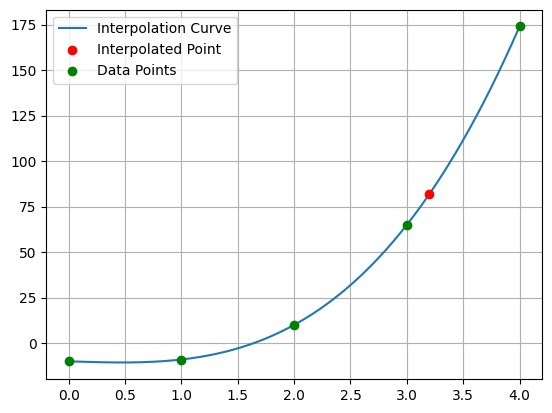

np.float64(81.90400000000002)

In [17]:
#Test 3.1
newtons_backward_interpolation(x2,x2_y2_bktable,3.2)

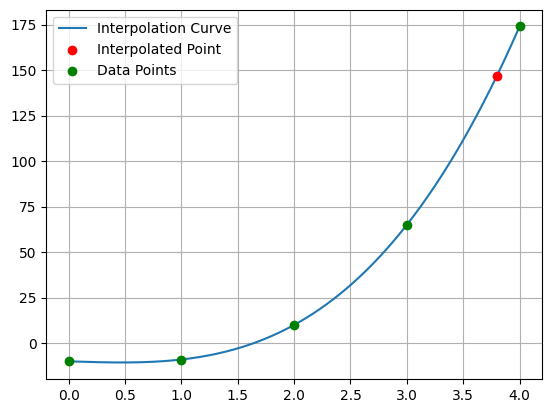

np.float64(147.016)

In [18]:
#Test 3.2
newtons_backward_interpolation(x2,x2_y2_bktable,3.8)

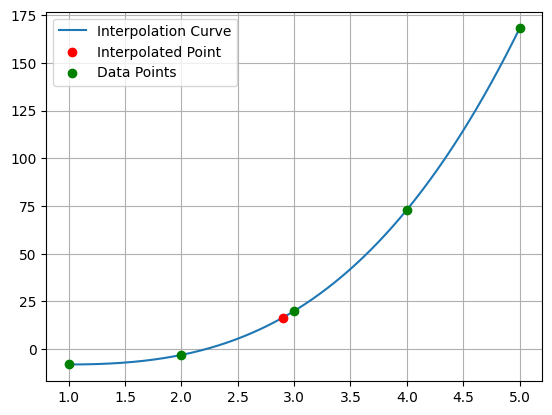

np.float64(16.548000000000012)

In [19]:
#Test 3.3
newtons_backward_interpolation(x1,x1_y1_bktable,2.9)

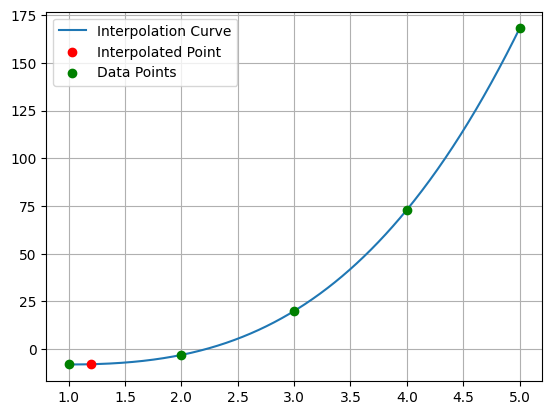

np.float64(-7.864000000000026)

In [20]:
#Test 3.4
newtons_backward_interpolation(x1,x1_y1_bktable,1.2)